# Turn-transition Labeling Script

In [1]:
import csv
import os
import numpy as np

""" HELPER FUNCTIONS FOR PROCESSING AUDIO DATA """
def GetSpeechEndingIndex(vol, start_index):
    if (vol[start_index] == 0):
        print("warning: starting speech index's volume is zero.") # could occur if sampling for non-speakers
    while (start_index < len(vol)):
        if (vol[start_index] == 0):
            break
        start_index += 1
    return min(len(vol)-1, start_index) # ending is indexed to the one after the ending index

def GetSpeechStartingAndEndingIndex(vol, start_index):
    end_idx = start_index
    start_idx = start_index
    
    if (vol[end_idx] == 0):
        print("warning: starting speech index's volume is zero.")
    while (end_idx < len(vol)):
        if (vol[end_idx] == 0):
            end_idx -= 1
            break
        end_idx += 1
    
    while (start_idx >= 0):
        if (vol[start_idx] == 0):
            start_idx += 1
            break
        start_idx -= 1 
    return start_idx, end_idx

def ExtractTurnTransitionBehaviors(id_name, audio_threshold = 0.1, root = "./Individual-based-all-raw/"):
    
    # load in individual user audio data associated with the week session "id_name"
    all_files = os.listdir(root)
    all_files
    filtered_files = []
    for file in all_files:
        if(id_name in file):
            filtered_files.append(file)
    if (len(filtered_files) == 0):
        
        # no files exist
        return [], [], [], [], [], [], [], []

    # initialize parameters
    timestamps = {}
    header = []
    all_names = []
    
    # extract audio data 
    for file in filtered_files:

        # extract participant name
        name = file.split("_")[-1]
        name = name[:len(name)-4]
        all_names.append(name)

        # process participant audio data file
        with open(root_path+file, mode ='r') as file:
            csvFile = csv.reader(file)
            line_count = 0
            for line in csvFile:    
                if line_count != 0:
                    ts = line[header.index('timestamp')]
                    if ts not in timestamps.keys():
                        timestamps[ts] = {}
                    timestamps[ts][name] = line[header.index('audio')]
                else:
                    
                    # save header
                    if header == []:
                        header = line
                line_count += 1

    # add in participant names for all timestamps
    for t in timestamps.keys():
        for name in all_names:
            if name not in timestamps[t].keys():
                timestamps[t][name] = 0

    # extract raw audio volume from the dataset
    audio_volumes = []
    for name in all_names:
        vol = []
        for t in timestamps.keys():
            vol.append((int)(float(timestamps[t][name])>=audio_threshold))

        # apply smoothing so that audio segments 0.5s apart are considered as one coherent speech, which is around 15 frames in the dataset
        idx = 1
        while idx < len(vol):
            if (vol[idx] == 0 and vol[idx-1] == 1):
                next_idx = idx+1
                filled = False
                while (next_idx <= min(idx + 15, len(vol)-1) and filled == False):
                    if (vol[next_idx] == 1):
                        
                        # fill gap as it is within 0.5s apart
                        for i in range(idx, next_idx):
                            vol[i] = 1
                        filled = True
                    else:
                        next_idx += 1
                if filled:
                    idx = next_idx
            idx += 1

        # append smoothed audio data to list
        audio_volumes.append(vol)

    # sort timestamps across all users
    sorted_timestamps = list(timestamps.keys())
    sorted_timestamps = [float(t) for t in sorted_timestamps]
    
    for i in range(len(audio_volumes)):
        audio_volume = audio_volumes[i]
        sorted_vol = [x for _,x in sorted(zip(sorted_timestamps,audio_volume))]
        audio_volumes[i] = sorted_vol
        
    sorted_timestamps.sort()
    
    """ determining main speaker & labelings of behaviors """
    main_speaker = [-1]*len(audio_volumes[0])

    complete_overlaps = [] # i.e., backchanneling in paper
    partial_overlaps = []
    clean_turn_transitions = []
    continuing_speech = []
    prev_speaker = -1 # updated to the previous speaker
    
    for i in range(len(sorted_timestamps)):
        speakers = []
        current_speaker = -1 # updated to the current speaker, -1 if no one was speaking
        
        for j in range(len(audio_volumes)):
            if (audio_volumes[j][i] > 0):
                speakers.append(j)
                
        if len(speakers) == 1:
            
            # single speaker, they are the main speaker
            main_speaker[i] = speakers[0]
            current_speaker = speakers[0]
                    
            # determine previous speaker
            prev_speaker_name = "NA"
            if (prev_speaker != -1):
                prev_speaker_name = all_names[prev_speaker]
            
            # categorize speech if a speaker has started to speak
            if (i == 0 or audio_volumes[speakers[0]][i-1] == 0):
    
                # new speech event
                endIdx = GetSpeechEndingIndex(audio_volumes[speakers[0]], i)
                if (speakers[0] == prev_speaker):
                    
                    # same speaker, classify as continuing speech
                    continuing_speech.append([all_names[speakers[0]], prev_speaker_name, sorted_timestamps[i], sorted_timestamps[min(len(sorted_timestamps)-1,endIdx)]])
                else:
                    
                    # new speaker, classify as clean turn transitions
                    clean_turn_transitions.append([all_names[speakers[0]], prev_speaker_name, sorted_timestamps[i], sorted_timestamps[min(len(sorted_timestamps)-1,endIdx)]])
            prev_speaker = speakers[0]
            
        elif len(speakers) > 1: # more than a single speaker
            
            # check for each speaker that is starting to speak
            speechDurations = []
            
            # initialize speech durations
            if speechDurations == []:
                
                # initialize speechDurations
                for s in speakers:
                    speechDurations.append(GetSpeechStartingAndEndingIndex(audio_volumes[s], i))
            
            for j in range(len(speakers)):
                speaker = speakers[j]
                if (i == 0 or audio_volumes[speaker][i-1] == 0): # speaker began speaking for the first time
                    
                    # check whether it is backchanneling
                    isBackchanneling = False
                    for k in range(len(speakers)):
                        examined_s = speakers[k]
                        if k != j:
                            if (speechDurations[k][0] <= speechDurations[j][0] and speechDurations[k][1] > speechDurations[j][1]):
                                
                                # since speaker j is completely overlapped by some other speaker, classify as backchanneling
                                isBackchanneling = True
                        if isBackchanneling:
                            break
                    
                    # determine the previous speaker
                    prev_speaker_name = "NA"
                    if (prev_speaker != -1):
                        prev_speaker_name = all_names[prev_speaker]

                    if all_names[speaker] == prev_speaker_name:
                        
                        # classify as continuing speech
                        speechDuration = speechDurations[speakers.index(speaker)]
                        continuing_speech.append([all_names[speaker], prev_speaker_name, sorted_timestamps[speechDuration[0]], sorted_timestamps[min(len(sorted_timestamps)-1,speechDuration[1])]])

                    elif isBackchanneling:
                        
                        # classify as complete overlap (i.e., backchanneling)
                        speechDuration = speechDurations[speakers.index(speaker)]
                        complete_overlaps.append([all_names[speaker], prev_speaker_name, sorted_timestamps[speechDuration[0]], sorted_timestamps[min(len(sorted_timestamps)-1,speechDuration[1])]])
                    
                    else:
                        
                        # classify as partial overlap
                        speechDuration = speechDurations[speakers.index(speaker)]
                        partial_overlaps.append([all_names[speaker], prev_speaker_name, sorted_timestamps[speechDuration[0]], sorted_timestamps[min(len(sorted_timestamps)-1,speechDuration[1])]])
            
            # determine the main speaker
            if prev_speaker in speakers:
                
                # if the previous speaker is still speaking, the main speaker does not change
                main_speaker[i] = prev_speaker
            else:
                
                # pick the speaker whose speech event ended last
                maxLastIdx = -1
                maxLastIdxspeaker = -1
                for k in range(len(speechDurations)):
                    speechDuration = speechDurations[k]
                    if (speechDuration[1] > maxLastIdx):
                        maxLastIdx = speechDuration[1]
                        maxLastIdxspeaker = speakers[k]
                        
                main_speaker[i] = maxLastIdxspeaker
                prev_speaker = main_speaker[i]

        else:
            # no speaker
            current_speaker = -1
            
    return sorted_timestamps, all_names, audio_volumes, main_speaker, partial_overlaps, complete_overlaps, clean_turn_transitions, continuing_speech

# Code for extracting and saving the labeled turn-transition behaviors

In [2]:
""" PARAMETER DEFINITION """
root_path = "./Individual-based-all-raw/"
csv_name = "./turn-transition-labels.csv"
main_speaker_root_dir = "./speaker-labels"
fields = ["week", "group", "behavior_label", "speaker", "prev_speaker", "starting_time", "ending_time"]
weeks = [3,4,5,6] # four weeks
groups = list(range(1,40)) # group number goes up to 40

In [ ]:
""" PROCESS RAW AUDIO FILES """
with open(csv_name, 'w') as csvfile:  
    
    # creating csv writer object  
    csvwriter = csv.writer(csvfile)  
    
    # writing headers  
    csvwriter.writerow(fields)  

    for week in weeks:
        for group in groups:
            print("Processing week", week, "group", group,"...",end = "")
            id_name = "week"+str(week)+"_group"+str(group)+"_"

            # extract turn transition behavior
            sorted_timestamps, all_names, audio_volumes, main_speaker, partial_overlaps, complete_overlaps, clean_turn_transitions, continuing_speech = ExtractTurnTransitionBehaviors(id_name)
            if sorted_timestamps == []:
                print("not found.") # week group session does not exist, then skip saving
            else:
                print("found.")
            
            if sorted_timestamps != []:
                """ saving the main speaker information """
                session_speech_data_csv_name = main_speaker_root_dir + "/week" + str(week) + "_group" + str(group) + "_speaker_labels.csv"
                with open(session_speech_data_csv_name, 'w') as file: 
                    
                    writer = csv.writer(file)  
                    
                    # writing headers  
                    writer.writerow(['timestamp','main_speaker'])  
                    
                    # write the main speaker information
                    for i in range(len(sorted_timestamps)):
                        if (main_speaker[i] == -1):
                            writer.writerow([sorted_timestamps[i], "NA"])
                        else:
                            writer.writerow([sorted_timestamps[i],all_names[main_speaker[i]]])

                """ saving turn transition behaviors """
                # clean turn transitions
                for entry in clean_turn_transitions:
                    csvwriter.writerow([week, group, "clean_turn_transition", entry[0], entry[1], entry[2], entry[3]])
                
                # partial overlaps
                for entry in partial_overlaps:
                    csvwriter.writerow([week, group, "partial_overlap", entry[0], entry[1], entry[2], entry[3]])
                    
                # continuing speech
                for entry in continuing_speech:
                    csvwriter.writerow([week, group, "continuing_speech", entry[0], entry[1], entry[2], entry[3]])
                    
                # complete_overlaps (i.e., backchanneling)
                for entry in complete_overlaps:
                    csvwriter.writerow([week, group, "complete_overlap", entry[0], entry[1], entry[2], entry[3]])     

# Exemplar Visualization

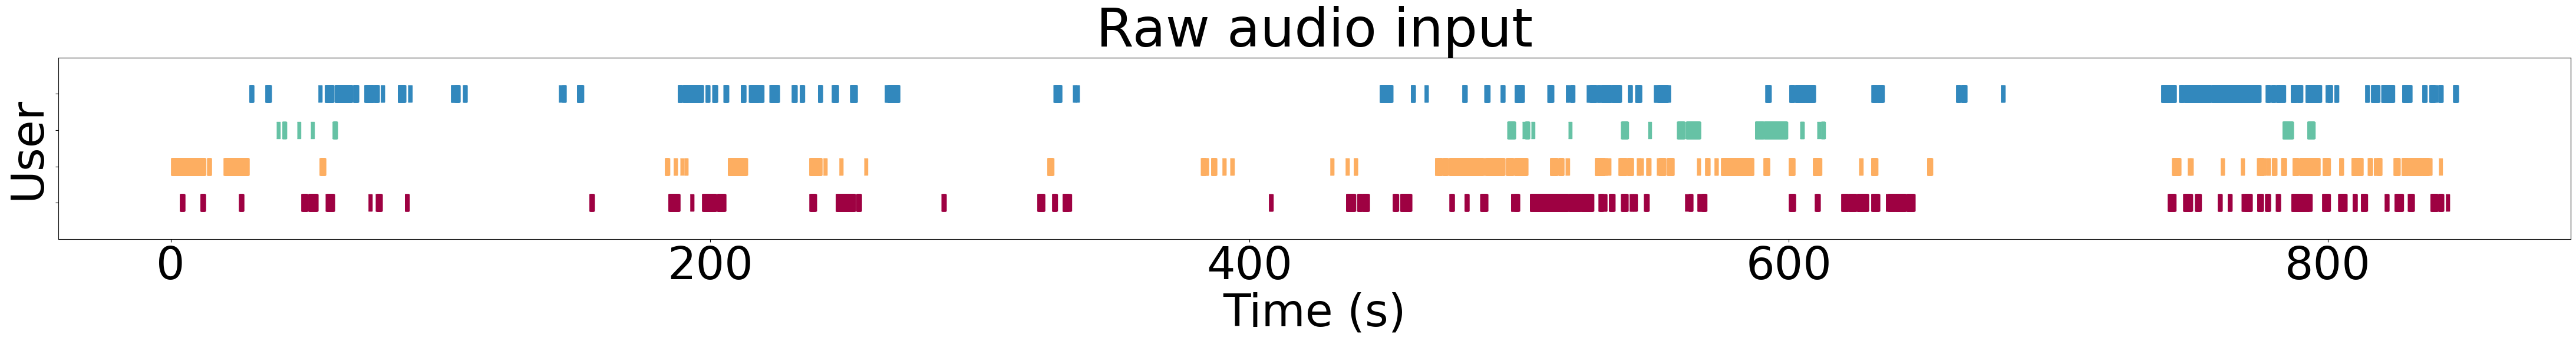

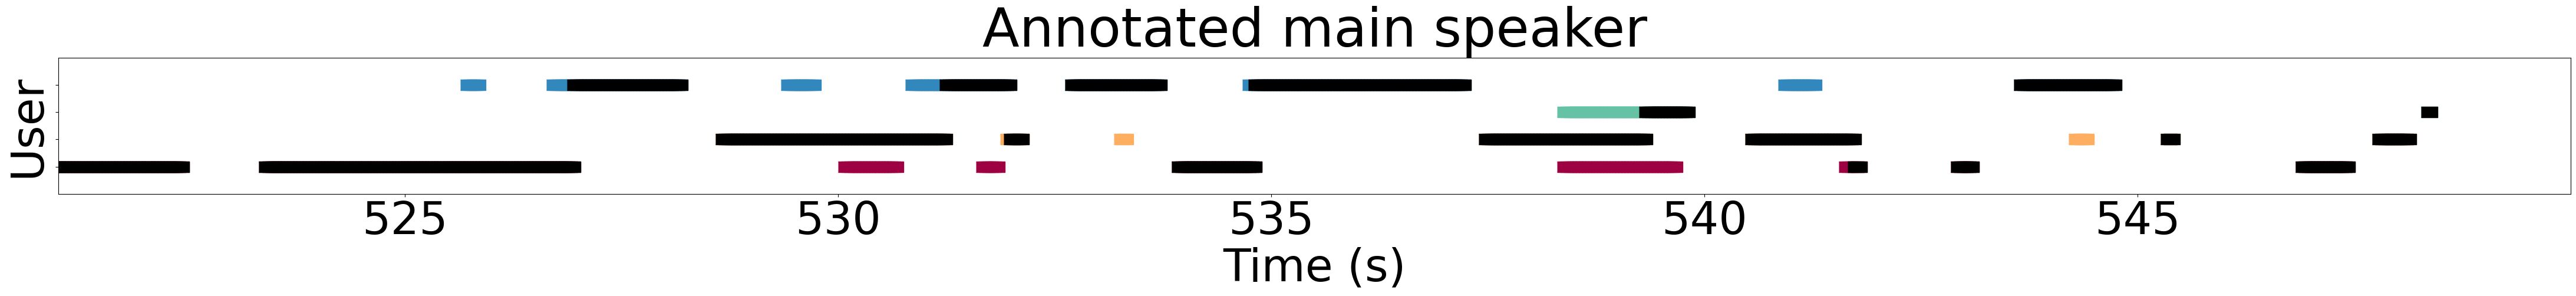

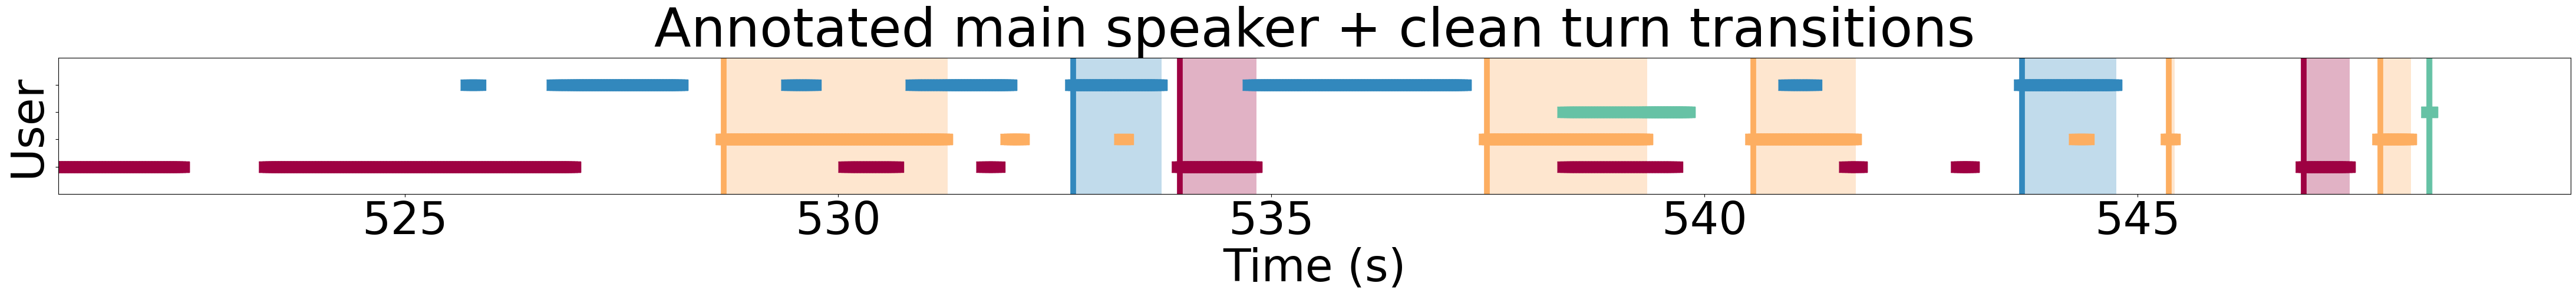

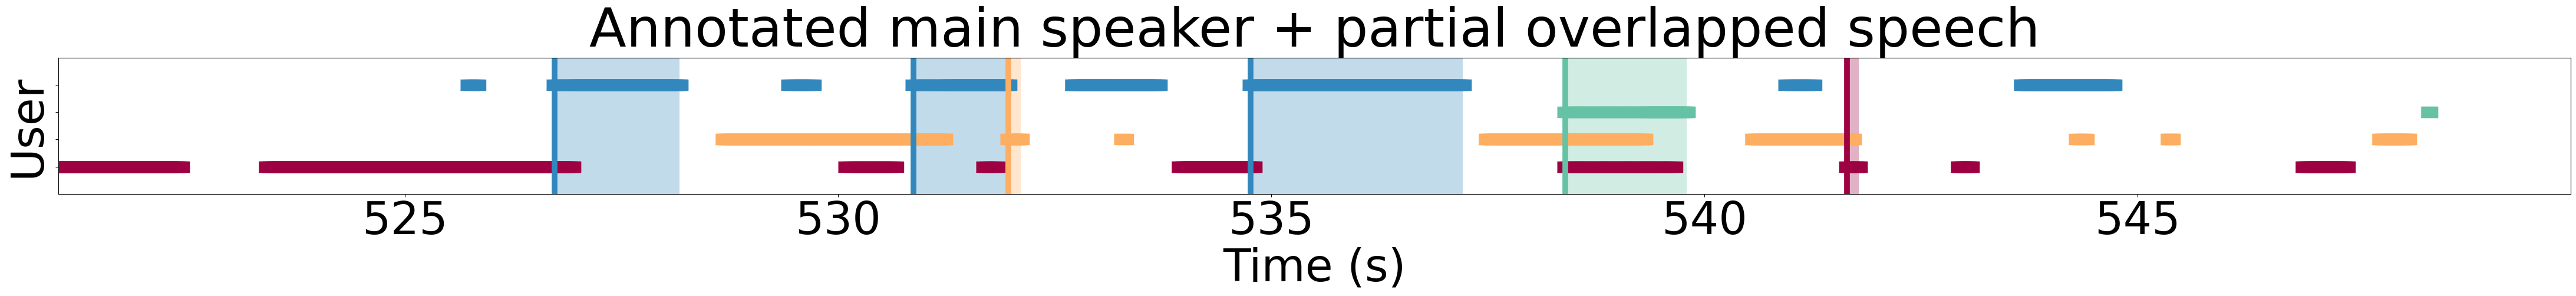

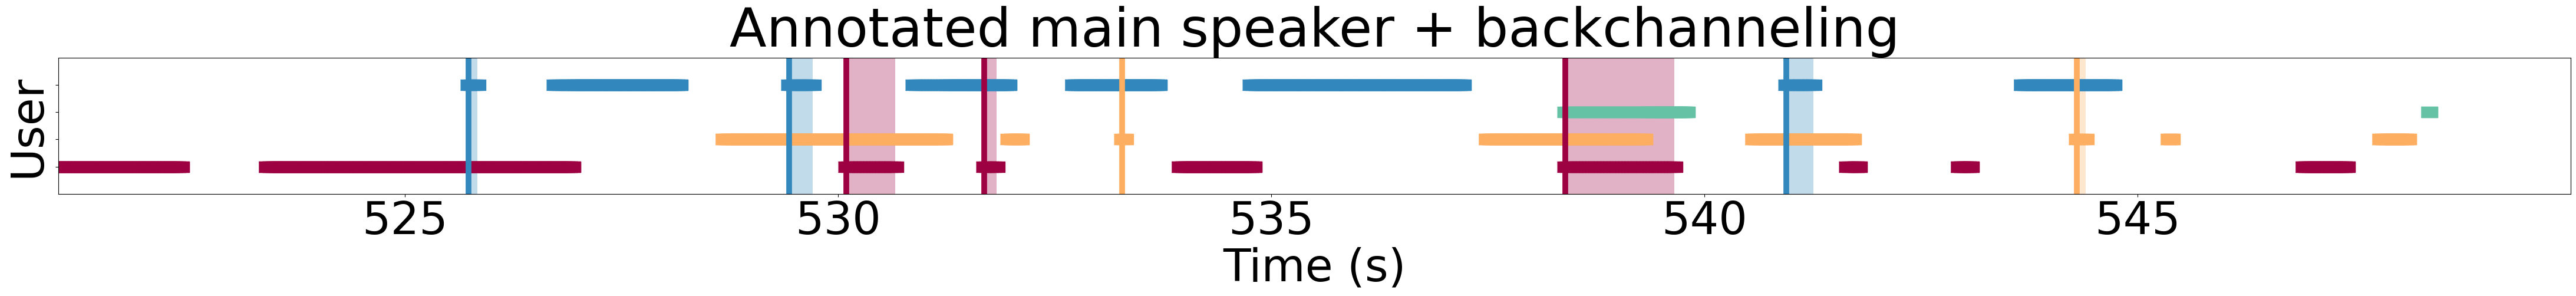

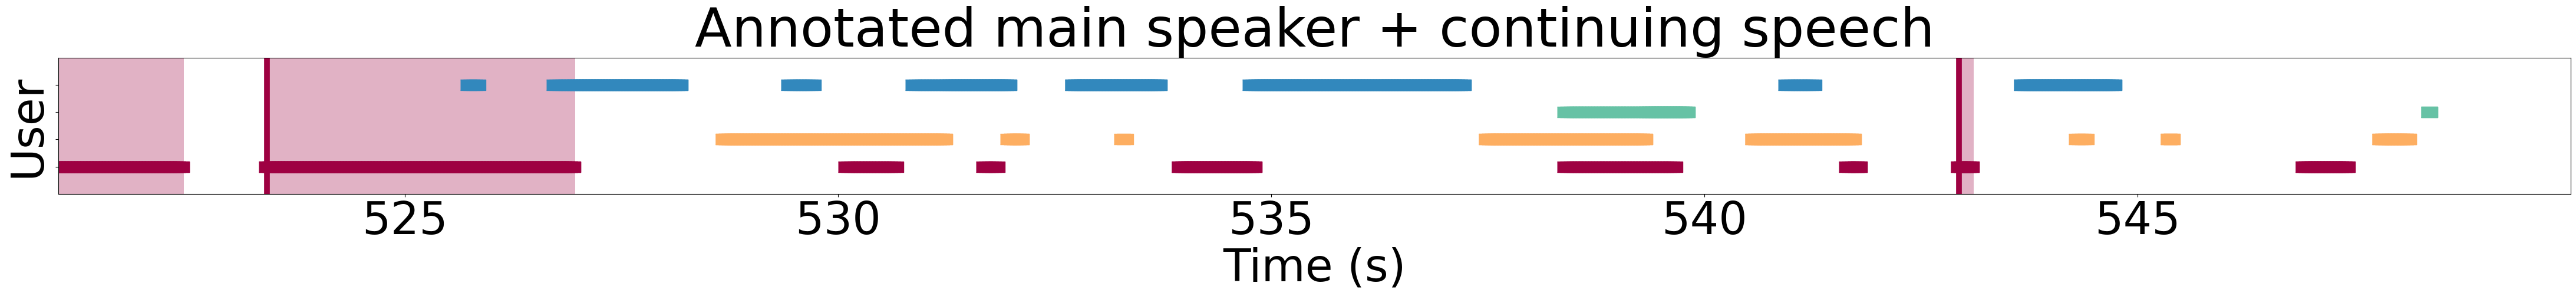

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib

""" INITIALIZE PARAMETER """
start_time = 0
end_time = 1000
data_id = "week4_group12_"
plt.rcParams.update({'font.size': 55})
fig_width = 55
fig_height = 3

# color definition
colors = ["#9e0142", "#fdae61", "#66c2a5", "#3288bd"] # red, orange, cyan, blue

# vertices definition 
width = 8
height = 5
verts = list(zip([-width,width,width,-width],[-height,-height,height,height]))

thin_width = 8
thin_height = 40
thin_verts = list(zip([-thin_width,thin_width,thin_width,-thin_width],[-thin_height,-thin_height,thin_height,thin_height]))

""" EXTRACT TURN-TRANSITION BEHAVIORS """
sorted_timestamps, all_names, audio_volumes, main_speaker, partial_overlaps, complete_overlaps, clean_turn_transitions, continuing_speech = ExtractTurnTransitionBehaviors(data_id)

concated_vols = []
concated_ts = []
all_ts = sorted_timestamps
for i in range(len(audio_volumes)):
    concated_vol = []
    for j in range(0, len(audio_volumes[i]), 1):
        scanned_vols = audio_volumes[i][j:min(len(audio_volumes[i]), j+1)]
        concated_vol.append(sum(scanned_vols)/len(scanned_vols))
        if i == 0:
            concated_ts.append(float(all_ts[j]))
    concated_vols.append(concated_vol)
              
""" PLOT RAW AUDIO INPUT """
fig, ax = plt.subplots()
ax.set_yticklabels("")
ax.set_yticks([0,1,2,3])
fig.set_figwidth(55)
fig.set_figheight(4)
for i in range(len(all_names)):
    plotted_ts = []
    speakers_ts = [] # marking out speaker
    for j in range(len(concated_ts)):
        if (concated_vols[i][j] != 0 and concated_ts[j]> start_time and concated_ts[j]< end_time):
            plotted_ts.append(concated_ts[j])
            if (main_speaker[j] == i):
                speakers_ts.append(concated_ts[j])
    ax.scatter(plotted_ts,[i]*len(plotted_ts), marker = thin_verts, color = colors[i], s = 400)
    
plt.ylim(-1,4)
plt.title("Raw audio input")
plt.xlabel("Time (s)")
plt.ylabel("User")
plt.savefig('./plots/categorization-figure/raw-audio-input.svg',format='svg')
plt.show()

""" PLOT MAIN SPEAKER """
fig, ax = plt.subplots()
ax.set_yticks([0,1,2,3])
ax.set_xticks(np.arange(520,550,5))
fig.set_figwidth(fig_width)
fig.set_figheight(fig_height)

for i in range(len(all_names)):
    plotted_ts = []
    speakers_ts = [] # marking out speaker
    for j in range(len(concated_ts)):
        if (concated_vols[i][j] != 0 and concated_ts[j] > start_time and concated_ts[j] < end_time):
            plotted_ts.append(concated_ts[j])
            if (main_speaker[j] == i):
                speakers_ts.append(concated_ts[j])
    ax.scatter(plotted_ts, [i] * len(plotted_ts), marker = verts, color = colors[i], s = 400)
    ax.scatter(speakers_ts, [i] * len(speakers_ts), marker = verts, color = "black", s = 400)

ax.set_yticklabels("")
plt.ylim(-1,4)
plt.xlim(521,550)
plt.title("Annotated main speaker")
plt.xlabel("Time (s)")
plt.ylabel("User")
plt.savefig('./plots/categorization-figure/main-speaker.svg',format='svg')
plt.show()

""" PLOT MAIN SPEAKER + CLEAN TURN TRANSITION """
fig, ax = plt.subplots()
ax.set_yticks([0,1,2,3])
ax.set_xticks(np.arange(520,550,5))
fig.set_figwidth(fig_width)
fig.set_figheight(fig_height)

for plotted_data in clean_turn_transitions:
    if plotted_data[2] > start_time and plotted_data[3] < end_time:
        color = colors[all_names.index(plotted_data[0])]
        ax.add_patch(Rectangle((plotted_data[2], -10), plotted_data[3]-plotted_data[2], 20,
                              facecolor = colors[all_names.index(plotted_data[0])],
                              alpha = 0.3))
for i in range(len(all_names)):
    plotted_ts = []
    speakers_ts = [] # marking out speaker
    for j in range(len(concated_ts)):
        if (concated_vols[i][j] != 0 and concated_ts[j]> start_time and concated_ts[j]< end_time):
            plotted_ts.append(concated_ts[j])
            if (main_speaker[j] == i):
                speakers_ts.append(concated_ts[j])
    ax.scatter(plotted_ts,[i]*len(plotted_ts), marker = verts, color = colors[i], s = 400)
    ax.scatter(speakers_ts, [i]*len(speakers_ts), marker = verts, color = colors[i], s = 400)
    
for plotted_data in clean_turn_transitions:
    if (plotted_data[2] > start_time and plotted_data[2] < end_time):
        plt.axvline(x = plotted_data[2], color = colors[all_names.index(plotted_data[0])], linewidth = 7)

ax.set_yticklabels("")
plt.ylim(-1,4)
plt.xlim(521,550)
plt.title("Annotated main speaker + clean turn transitions")
plt.xlabel("Time (s)")
plt.ylabel("User")
plt.savefig('./plots/categorization-figure/clean-turn-transition.svg',format='svg')
plt.show()

""" PLOT MAIN SPEAKER + PARTIAL TURN TRANSITIONS """
fig, ax = plt.subplots()
ax.set_yticks([0,1,2,3])
ax.set_xticks(np.arange(520,550,5))
fig.set_figwidth(fig_width)
fig.set_figheight(fig_height)

for plotted_data in partial_overlaps:
    if plotted_data[2] > start_time and plotted_data[3] < end_time:
        color = colors[all_names.index(plotted_data[0])]
        ax.add_patch(Rectangle((plotted_data[2], -10), plotted_data[3]-plotted_data[2], 20,
                              facecolor = colors[all_names.index(plotted_data[0])],
                              alpha = 0.3))

for i in range(len(all_names)):
    plotted_ts = []
    speakers_ts = [] # marking out speaker
    for j in range(len(concated_ts)):
        if (concated_vols[i][j] != 0 and concated_ts[j] > start_time and concated_ts[j] < end_time):
            plotted_ts.append(concated_ts[j])
            if (main_speaker[j] == i):
                speakers_ts.append(concated_ts[j])
    ax.scatter(plotted_ts,[i]*len(plotted_ts), marker = verts, color = colors[i], s = 400)
    ax.scatter(speakers_ts, [i]*len(speakers_ts), marker = verts, color = colors[i], s = 400)
    
for plotted_data in partial_overlaps:
    if (plotted_data[2] > start_time and plotted_data[2] < end_time):
        plt.axvline(x = plotted_data[2], color = colors[all_names.index(plotted_data[0])], linewidth = 7)

ax.set_yticklabels("")
plt.ylim(-1,4)
plt.xlim(521,550)
plt.title("Annotated main speaker + partial overlapped speech")
plt.xlabel("Time (s)")
plt.ylabel("User")
plt.savefig('./plots/categorization-figure/partial-overlap.svg',format='svg')
plt.show()

""" PLOT MAIN SPEAKER + BACKCHANNELING """
fig, ax = plt.subplots()
ax.set_yticks([0,1,2,3])
ax.set_xticks(np.arange(520,550,5))
fig.set_figwidth(fig_width)
fig.set_figheight(fig_height)

for plotted_data in complete_overlaps:
    if plotted_data[2] > start_time and plotted_data[3] < end_time:
        color = colors[all_names.index(plotted_data[0])]
        ax.add_patch(Rectangle((plotted_data[2], -10), plotted_data[3]-plotted_data[2], 20,
                              facecolor = colors[all_names.index(plotted_data[0])],
                              alpha = 0.3))

for i in range(len(all_names)):
    plotted_ts = []
    speakers_ts = [] # marking out speaker
    for j in range(len(concated_ts)):
        if (concated_vols[i][j] != 0 and concated_ts[j]> start_time and concated_ts[j] < end_time):
            plotted_ts.append(concated_ts[j])
            if (main_speaker[j] == i):
                speakers_ts.append(concated_ts[j])
    ax.scatter(plotted_ts,[i]*len(plotted_ts), marker = verts, color = colors[i], s = 400)
    ax.scatter(speakers_ts, [i]*len(speakers_ts), marker = verts, color = colors[i], s = 400)
    
# plotting partial transitions
for plotted_data in complete_overlaps:
    if (plotted_data[2] > start_time and plotted_data[2] < end_time):
        plt.axvline(x = plotted_data[2], color = colors[all_names.index(plotted_data[0])], linewidth = 7)

ax.set_yticklabels("")
plt.ylim(-1,4)
plt.xlim(521,550)
plt.title("Annotated main speaker + backchanneling")
plt.xlabel("Time (s)")
plt.ylabel("User")
plt.savefig('./plots/categorization-figure/backchanneling.svg',format='svg')
plt.show()

""" PLOT MAIN SPEAKER + CONTINUING SPEECH """
fig, ax = plt.subplots()
ax.set_yticks([0,1,2,3])
ax.set_xticks(np.arange(520,550,5))
fig.set_figwidth(fig_width)
fig.set_figheight(fig_height)

for plotted_data in continuing_speech:
    if plotted_data[2] > start_time and plotted_data[3] < end_time:
        color = colors[all_names.index(plotted_data[0])]
        ax.add_patch(Rectangle((plotted_data[2], -10), plotted_data[3]-plotted_data[2], 20,
                              facecolor = colors[all_names.index(plotted_data[0])],
                              alpha = 0.3))

for i in range(len(all_names)):
    plotted_ts = []
    speakers_ts = [] # marking out speaker
    for j in range(len(concated_ts)):
        if (concated_vols[i][j] != 0 and concated_ts[j]> start_time and concated_ts[j] < end_time):#
            plotted_ts.append(concated_ts[j])
            if (main_speaker[j] == i):
                speakers_ts.append(concated_ts[j])
    ax.scatter(plotted_ts,[i]*len(plotted_ts), marker = verts, color = colors[i], s = 400)
    ax.scatter(speakers_ts, [i]*len(speakers_ts), marker = verts, color = colors[i], s = 400)
    
for plotted_data in continuing_speech:
    if (plotted_data[2] > start_time and plotted_data[2] < end_time):
        plt.axvline(x = plotted_data[2], color = colors[all_names.index(plotted_data[0])], linewidth = 7)
        
ax.set_yticklabels("")
plt.ylim(-1,4)
plt.xlim(521,550)
plt.title("Annotated main speaker + continuing speech")
plt.xlabel("Time (s)")
plt.ylabel("User")
plt.savefig('./plots/categorization-figure/continuing-speech.svg',format='svg')
plt.show()